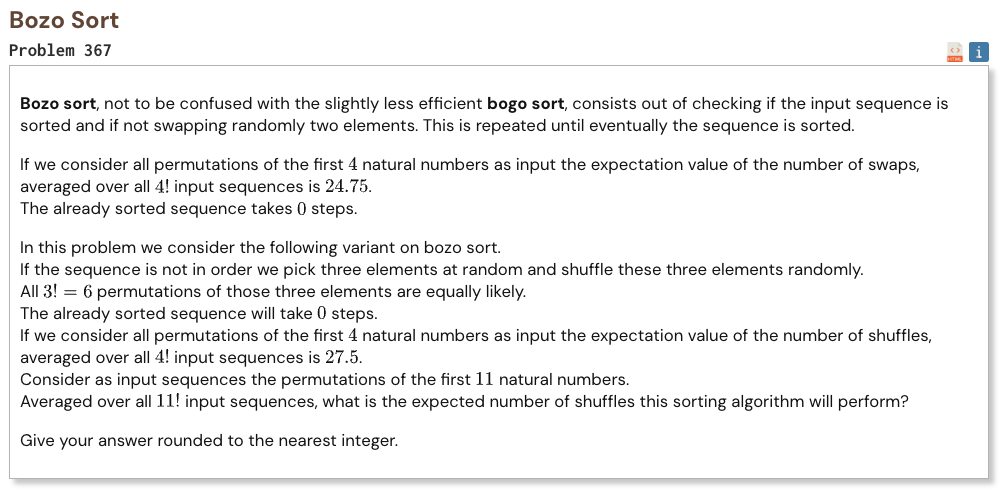

## Initial approach

* group permutations by cycle structure instead of listing every permutation
* each group becomes one Markov state
* use itertools to generate the chosen three positions and their six shuffles
* build transition probabilities between cycle structures
* solve the expected-time linear system
* average the expectations using permutation class sizes
* round the final expectation to the nearest integer

In [1]:
from itertools import combinations, permutations
from collections import Counter
from math import factorial

def integer_partitions(n, max_part=None):
    if max_part is None:
        max_part = n

    if n == 0:
        yield ()
        return

    for first in range(min(max_part, n), 0, -1):
        for rest in integer_partitions(n - first, first):
            yield (first,) + rest

def representative(partition):
    n = sum(partition)
    perm = list(range(n))
    start = 0

    for length in partition:
        for i in range(length):
            perm[start + i] = start + (i + 1) % length
        start += length

    return tuple(perm)

def cycle_type(perm):
    n = len(perm)
    seen = [False] * n
    lengths = []

    for i in range(n):
        if not seen[i]:
            current = i
            length = 0

            while not seen[current]:
                seen[current] = True
                length += 1
                current = perm[current]

            lengths.append(length)

    return tuple(sorted(lengths, reverse=True))

def apply_shuffle(perm, indices, order):
    new_perm = list(perm)
    old_values = [perm[i] for i in indices]

    for i, index in enumerate(indices):
        new_perm[index] = old_values[order[i]]

    return tuple(new_perm)

def class_size(partition):
    n = sum(partition)
    counts = Counter(partition)
    denominator = 1

    for length, count in counts.items():
        denominator *= (length ** count) * factorial(count)

    return factorial(n) // denominator

def solve_linear(matrix, values):
    n = len(values)

    for col in range(n):
        pivot = col

        for row in range(col + 1, n):
            if abs(matrix[row][col]) > abs(matrix[pivot][col]):
                pivot = row

        matrix[col], matrix[pivot] = matrix[pivot], matrix[col]
        values[col], values[pivot] = values[pivot], values[col]

        div = matrix[col][col]

        for j in range(col, n):
            matrix[col][j] /= div

        values[col] /= div

        for row in range(n):
            if row == col:
                continue

            factor = matrix[row][col]

            if factor == 0:
                continue

            for j in range(col, n):
                matrix[row][j] -= factor * matrix[col][j]

            values[row] -= factor * values[col]

    return values

def expected_average(n):
    partitions = list(integer_partitions(n))
    index = {partition: i for i, partition in enumerate(partitions)}
    identity = tuple([1] * n)
    identity_index = index[identity]

    triples = list(combinations(range(n), 3))
    orders = list(permutations(range(3)))
    state_count = len(partitions)

    transition = [[0.0] * state_count for _ in range(state_count)]

    for partition in partitions:
        row = index[partition]
        perm = representative(partition)
        counts = Counter()

        for triple in triples:
            for order in orders:
                new_perm = apply_shuffle(perm, triple, order)
                counts[cycle_type(new_perm)] += 1

        total = len(triples) * len(orders)

        for target, count in counts.items():
            transition[row][index[target]] = count / total

    active = [i for i in range(state_count) if i != identity_index]
    size = len(active)

    matrix = [[0.0] * size for _ in range(size)]
    values = [1.0] * size

    for i, state_i in enumerate(active):
        for j, state_j in enumerate(active):
            matrix[i][j] = (1.0 if i == j else 0.0) - transition[state_i][state_j]

    solved = solve_linear(matrix, values)

    expectations = [0.0] * state_count

    for value, state in zip(solved, active):
        expectations[state] = value

    total = 0.0
    n_factorial = factorial(n)

    for partition in partitions:
        total += class_size(partition) * expectations[index[partition]] / n_factorial

    return total

In [2]:
%%time
result = round(expected_average(11))
print("Result:", result)

Result: 48271207
CPU times: user 69.6 ms, sys: 1.13 ms, total: 70.7 ms
Wall time: 70.3 ms
